# EDA(cleaned_gurgaon_v2.csv)
    1) Univariate Analysis
    2) Multivariate Analysis

    here in this notebook i will perform 'Univariate Anlaysis'

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:\\capstone_project_dscience\\real_estate_project\\dataset\\cleaned_gurgaon_v2.csv')

In [31]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [22]:
df.shape

(3807, 30)

In [23]:
df = df.sample(df.shape[0])

In [24]:
df.duplicated().sum()

np.int64(131)

    there are 131 duplicate values, so let's first remove it

In [25]:
df.drop_duplicates(inplace=True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 3676 entries, 2263 to 3611
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3676 non-null   str    
 1   sector               3676 non-null   str    
 2   society              3238 non-null   str    
 3   price                3675 non-null   float64
 4   price_per_sqft       3675 non-null   float64
 5   area                 3675 non-null   float64
 6   super_built_up_area  1888 non-null   float64
 7   built_up_area        2870 non-null   float64
 8   carpet_area          1888 non-null   float64
 9   bedRoom              3676 non-null   float64
 10  bathroom             3676 non-null   float64
 11  balcony              3676 non-null   str    
 12  floorNum             3658 non-null   float64
 13  agePossession        3675 non-null   str    
 14  store room           3676 non-null   int64  
 15  servant room         3676 non-null   int64  
 16  p

 **property_type**

In [27]:
df['property_type'].value_counts()

property_type
flat     2889
house     787
Name: count, dtype: int64

<Axes: xlabel='property_type', ylabel='count'>

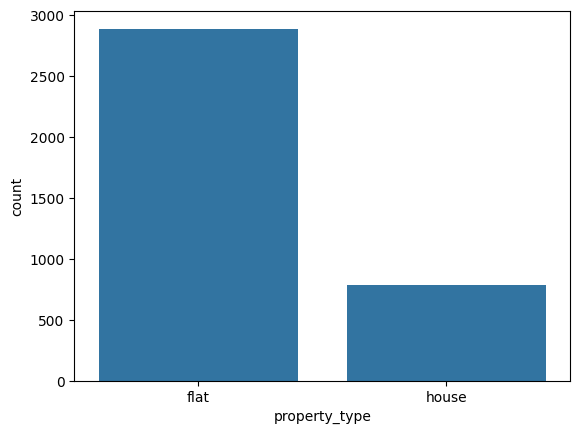

In [28]:
sns.barplot(df['property_type'].value_counts())

**sector**

In [ ]:
df['sector'].value_counts()

sector
sohna                      158
sector 37                  119
sector 85                  111
sector 102                 107
sector 70                  104
sector 92                   99
sector 69                   94
sector 90                   88
sector 81                   87
sector 65                   87
sector 109                  81
sector 1                    80
sector 79                   76
sector 33                   74
sector 104                  74
sector 67                   70
sector 83                   68
sector 89                   66
sector 86                   65
sector 95                   62
sector 50                   62
sector 107                  60
sector 82                   60
sector 108                  59
sector 43                   58
sector 48                   55
sector 56                   55
sector 49                   49
sector 84                   49
sector 26                   48
sector 113                  46
sector 61                   46
s

In [49]:
df[df['sector'] == 'new']

,property_type,sector,society,price,price_per_sqft,area,super_built_up_area,built_up_area,carpet_area,bedRoom,bathroom,balcony,floorNum,agePossession,store room,servant room,puja room,study room,others,East,North,North-East,North-West,South,South-East,South-West,Unknown,West,furnish_type,luxury_score
2887,flat,new,dlf,4.00,11428.0,3500.18,NaN,NaN,3500.0,4.0,4.0,2,4.0,under construction,0,1,0,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2,313.0
3771,flat,new,sare homes,0.85,4786.0,1776.01,1776.0,1776.0,NaN,4.0,4.0,3,3.0,moderately old,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,NaN
3619,flat,new,takshila heights sector c,0.67,5583.0,1200.07,1200.0,1200.0,NaN,2.0,2.0,2,3.0,relatively new,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,104.0
3708,flat,new,green court,0.38,5507.0,690.03,NaN,NaN,690.0,2.0,2.0,1,7.0,unknown,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,97.0


    replace sector of index:
    2887 -> sector 42
    3771 -> sector 49
    3619 -> sector 37
    3708 -> sector 90

In [53]:
df.loc[2887,'sector'] = 'sector 42'
df.loc[3771,'sector'] = 'sector 49'
df.loc[3619,'sector'] = 'sector 37'
df.loc[3708,'sector'] = 'sector 90'

    here as there are so many sectors, i will plot only the top 10, to avoid congestion.

<Axes: xlabel='sector'>

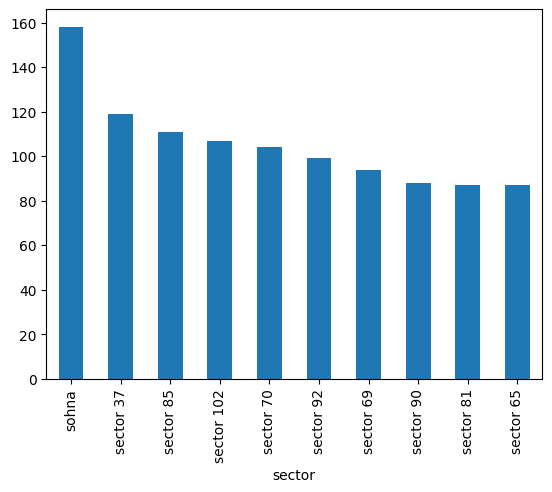

In [37]:
df['sector'].value_counts()[:10].plot(kind='bar')

    now lets make frequency bins. so for this i have to make bins.
        1) 'very high(>100)' : if sector_count > 100
        2) 'high' : if 60<sector_count<100
        3) 'moderate' : if 20<sector_count<60
        4) 'low' : if 5<sector_count<20
        5) 'very low' : if sector_count <5

In [38]:
sector_count = df['sector'].value_counts()

In [45]:
frequency_bins = {
    'very high(>100)' : (sector_count > 100).sum(),
    'high(50-100)' : ((sector_count > 50) & (sector_count <= 100)).sum(),
    'medium(10-50)' : ((sector_count > 10) & (sector_count <= 50)).sum(),
    'low(1-10)' : ((sector_count > 1) & (sector_count <= 10)).sum(),
    'very low(<=1)' : (sector_count <= 1).sum()
}

frequency_bins

{'very high(>100)': np.int64(5),
 'high(50-100)': np.int64(22),
 'medium(10-50)': np.int64(50),
 'low(1-10)': np.int64(26),
 'very low(<=1)': np.int64(0)}

In [46]:
df['sector'].isnull().sum()

np.int64(0)

In [54]:
df['sector'].unique().shape

(103,)

    Observations:
    1) there are a total of 103 unique sectors in the dataset
    2)  frequency distribution:
        'very high(>100)': 5 sectors have more than 100 frequency,
        'high(50-100)': 22 sectors have more than 50 and less than 100 frequency,
        'medium(10-50)': 50 sectors have more than 10 and less than 50 frequency,
        'low(1-10)': 26 sectors have more than 1 and less than 10 frequency,
        'very low(<=1)': 0 sectors have more than or equal to 1 frequency
    